# Federated Learning — Image Branch (Malimg CNN)
### FINAL MEMORY-OPTIMIZED VERSION

**Memory fixes applied:**
- ✅ Data cast to float16 (halves RAM: 1.4GB → 700MB)
- ✅ Client models loaded ONCE outside loop (no TF graph leak)
- ✅ Client data loaded ONE AT A TIME (never both in RAM together)
- ✅ Checkpoint saved every 2 rounds

⚠️ **Set runtime to T4 GPU FIRST:** Runtime → Change runtime type → T4 GPU

In [1]:
# ═══════════════════════════════════════
# CELL 1 — Imports & GPU Check
# ═══════════════════════════════════════
import os, gc, json, pickle, warnings
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

print(f'TensorFlow : {tf.__version__}')
gpu = tf.config.list_physical_devices('GPU')
print(f'GPU        : {gpu}')
if not gpu:
    raise RuntimeError('NO GPU! Go to Runtime → Change runtime type → T4 GPU')
print('✅ GPU ready')

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU ready


In [2]:
# ═══════════════════════════════════════
# CELL 2 — Mount Drive & Config
# ═══════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

PATHS = {
    'data'   : '/content/drive/MyDrive/FYP_Processed_Data',
    'models' : '/content/drive/MyDrive/FYP_Models',
    'clients': '/content/drive/MyDrive/FYP_Local_Clients',
    'output' : '/content/drive/MyDrive/FYP_Federated',
}
os.makedirs(PATHS['output'], exist_ok=True)

FL_CONFIG = {
    'num_rounds'   : 10,
    'local_epochs' : 5,
    'batch_size'   : 32,
    'learning_rate': 1e-4,
}

# File paths for client data
C3_X = f"{PATHS['data']}/X_client3.npy"
C3_Y = f"{PATHS['data']}/y_client3.npy"
C4_X = f"{PATHS['data']}/X_client4.npy"
C4_Y = f"{PATHS['data']}/y_client4.npy"

print('Config:', FL_CONFIG)
print('✅ Ready')

Mounted at /content/drive
Config: {'num_rounds': 10, 'local_epochs': 5, 'batch_size': 32, 'learning_rate': 0.0001}
✅ Ready


In [3]:
# ═══════════════════════════════════════
# CELL 3 — Create Client Splits (one-time)
# ═══════════════════════════════════════
if not os.path.exists(C3_X):
    print('Creating client splits (one-time only)...')
    X_train = np.load(f"{PATHS['data']}/X_train.npy")
    y_train = np.load(f"{PATHS['data']}/y_train.npy")
    y_int = np.argmax(y_train, axis=1)
    X_c3, X_c4, y_c3, y_c4 = train_test_split(
        X_train, y_train, test_size=0.5, stratify=y_int, random_state=42)
    np.save(C3_X, X_c3); np.save(C4_X, X_c4)
    np.save(C3_Y, y_c3); np.save(C4_Y, y_c4)
    del X_train, y_train, X_c3, X_c4, y_c3, y_c4, y_int
    gc.collect()
    print('✅ Client splits saved')
else:
    print('✅ Client splits already exist on Drive')

# Check sizes using memory-map (zero RAM cost)
N_C3 = np.load(C3_X, mmap_mode='r').shape[0]
N_C4 = np.load(C4_X, mmap_mode='r').shape[0]
print(f'Client 3: {N_C3} samples | Client 4: {N_C4} samples')

✅ Client splits already exist on Drive
Client 3: 10966 samples | Client 4: 10966 samples


In [4]:
# ═══════════════════════════════════════
# CELL 4 — Load Test Data as float16
#
# YOUR FRIEND'S SUGGESTION IS CORRECT.
# float32 → float16 halves memory:
#   X_test: 308MB → 154MB
# Models still train in float32 internally.
# Accuracy is NOT affected.
# ═══════════════════════════════════════
print('Loading test data as float16...')

X_test = np.load(f"{PATHS['data']}/X_test.npy").astype(np.float16)
y_test = np.load(f"{PATHS['data']}/y_test.npy").astype(np.float16)

print(f'X_test : {X_test.shape}  dtype={X_test.dtype}  {X_test.nbytes/1e6:.0f} MB')
print(f'y_test : {y_test.shape}  dtype={y_test.dtype}')

with open(f"{PATHS['models']}/label_encoder.pkl", 'rb') as f:
    le = pickle.load(f)
class_names = le.classes_.tolist()
print(f'Classes: {len(class_names)}')
print('✅ Test data loaded (float16 — half the RAM)')

Loading test data as float16...
X_test : (4700, 128, 128, 1)  dtype=float16  154 MB
y_test : (4700, 60)  dtype=float16
Classes: 60
✅ Test data loaded (float16 — half the RAM)


In [5]:
# ═══════════════════════════════════════
# CELL 5 — Baseline Evaluation
# ═══════════════════════════════════════
def eval_model(model, name):
    model.compile(optimizer=Adam(1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    # Evaluate in small batches — avoids GPU OOM
    correct = 0
    total   = 0
    for i in range(0, len(X_test), 100):
        xb    = X_test[i:i+100].astype(np.float32)
        yb    = y_test[i:i+100].astype(np.float32)
        preds = model.predict_on_batch(xb)
        correct += np.sum(np.argmax(preds, axis=1) == np.argmax(yb, axis=1))
        total   += len(xb)
    acc = correct / total
    print(f'  {name:<35}: {acc*100:.2f}%')
    return acc

print('BASELINE PERFORMANCE')
print('=' * 52)

m = load_model(f"{PATHS['models']}/best_model.h5", compile=False)
central_acc = eval_model(m, 'Centralized CNN (upper bound)')
del m; gc.collect()

m = load_model(f"{PATHS['clients']}/client3_best_model.h5", compile=False)
client3_acc = eval_model(m, 'Client 3 Local CNN')
del m; gc.collect()

m = load_model(f"{PATHS['clients']}/client4_best_model.h5", compile=False)
client4_acc = eval_model(m, 'Client 4 Local CNN')
del m; gc.collect()

print(f'\n  Privacy cost C3: -{(central_acc-client3_acc)*100:.2f}%')
print(f'  Privacy cost C4: -{(central_acc-client4_acc)*100:.2f}%')

BASELINE PERFORMANCE
  Centralized CNN (upper bound)      : 89.28%
  Client 3 Local CNN                 : 83.89%
  Client 4 Local CNN                 : 88.26%

  Privacy cost C3: -5.38%
  Privacy cost C4: -1.02%


In [6]:
# ═══════════════════════════════════════
# CELL 6 — FedAvg Functions
# ═══════════════════════════════════════
def fedavg_aggregate(weights_list, num_samples_list):
    """Federated Averaging — McMahan et al. (2017)"""
    total = sum(num_samples_list)
    return [
        sum((n / total) * w[i]
            for w, n in zip(weights_list, num_samples_list))
        for i in range(len(weights_list[0]))
    ]

print('✅ FedAvg defined (McMahan et al. 2017)')

✅ FedAvg defined (McMahan et al. 2017)


In [8]:
# ═══════════════════════════════════════
# CELL 7 — Initialize Global Model
# ═══════════════════════════════════════
global_model = load_model(
    f"{PATHS['clients']}/client3_best_model.h5", compile=False)
global_model.compile(
    optimizer=Adam(FL_CONFIG['learning_rate']),
    loss='categorical_crossentropy', metrics=['accuracy'])

correct = 0
total   = 0
for i in range(0, len(X_test), 100):
    xb    = X_test[i:i+100].astype(np.float32)
    yb    = y_test[i:i+100].astype(np.float32)
    preds = global_model.predict_on_batch(xb)
    correct += np.sum(np.argmax(preds,1) == np.argmax(yb,1))
    total   += len(xb)
rnd_acc = correct / total
print(f'Global model Round 0: {rnd_acc*100:.2f}%')

metrics = {
    'round'            : [0],
    'global_acc'       : [rnd_acc],
    'client3_train_acc': [client3_acc],
    'client4_train_acc': [client4_acc],
}
print('✅ Ready for federated training')

Global model Round 0: 83.89%
✅ Ready for federated training


In [11]:
# ═══════════════════════════════════════════════════════════
# CELL 8 — FEDERATED TRAINING LOOP (FINAL VERSION)
# ═══════════════════════════════════════════════════════════

# Reduce batch size to prevent ResourceExhaustedError on T4 GPU.
# The original batch_size of 32 might still be too large for the model.
FL_CONFIG['batch_size'] = 16

# Load client models ONCE outside loop
print('Loading client models once (outside loop)...')
client3_model = load_model(
    f"{PATHS['clients']}/client3_best_model.h5", compile=False)
client3_model.compile(
    optimizer=Adam(FL_CONFIG['learning_rate']),
    loss='categorical_crossentropy', metrics=['accuracy'])

client4_model = load_model(
    f"{PATHS['clients']}/client4_best_model.h5", compile=False)
client4_model.compile(
    optimizer=Adam(FL_CONFIG['learning_rate']),
    loss='categorical_crossentropy', metrics=['accuracy'])
print('✅ Client models ready')

print('\n' + '=' * 62)
print('FEDERATED LEARNING — IMAGE BRANCH (FedAvg)')
print(f'  Rounds       : {FL_CONFIG["num_rounds"]}')
print(f'  Local epochs : {FL_CONFIG["local_epochs"]} per client per round')
print(f'  Clients      : Client 3 ({N_C3:,}) + Client 4 ({N_C4:,})')
print('=' * 62)

def train_on_batches(model, X, y, epochs, batch_size):
    """
    Trains model batch by batch — never sends full array to GPU.
    Avoids InternalError: Dst tensor is not initialized.
    """
    history = {'accuracy': []}
    for ep in range(epochs):
        idx    = np.random.permutation(len(X))
        ep_acc = []
        for i in range(0, len(X), batch_size):
            bi       = idx[i:i + batch_size]
            # Cast mini-batches to float32 for training (model expects float32)
            _, acc   = model.train_on_batch(X[bi].astype(np.float32), y[bi].astype(np.float32))
            ep_acc.append(acc)
        history['accuracy'].append(float(np.mean(ep_acc)))
    return history

for rnd in range(1, FL_CONFIG['num_rounds'] + 1):
    print(f'\n── Round {rnd}/{FL_CONFIG["num_rounds"]} ──')
    current_weights = global_model.get_weights()

    # ── CLIENT 3 ──────────────────────────────────────────
    print('  Client 3: loading data...', end=' ')
    # Load as float16 for memory efficiency
    X_c3 = np.load(C3_X).astype(np.float16)
    y_c3 = np.load(C3_Y).astype(np.float16)
    print(f'{X_c3.nbytes/1e6:.0f} MB')

    client3_model.set_weights(current_weights)
    hist3        = train_on_batches(client3_model, X_c3, y_c3,
                                    FL_CONFIG['local_epochs'],
                                    FL_CONFIG['batch_size'])
    c3_weights   = client3_model.get_weights()
    c3_train_acc = hist3['accuracy'][-1]

    del X_c3, y_c3
    gc.collect()
    print(f'  Client 3 done → train_acc={c3_train_acc*100:.2f}%  🧹 freed')

    # ── CLIENT 4 ──────────────────────────────────────────
    print('  Client 4: loading data...', end=' ')
    # Load as float16 for memory efficiency
    X_c4 = np.load(C4_X).astype(np.float16)
    y_c4 = np.load(C4_Y).astype(np.float16)
    print(f'{X_c4.nbytes/1e6:.0f} MB')

    client4_model.set_weights(current_weights)
    hist4        = train_on_batches(client4_model, X_c4, y_c4,
                                    FL_CONFIG['local_epochs'],
                                    FL_CONFIG['batch_size'])
    c4_weights   = client4_model.get_weights()
    c4_train_acc = hist4['accuracy'][-1]

    del X_c4, y_c4
    gc.collect()
    print(f'  Client 4 done → train_acc={c4_train_acc*100:.2f}%  🧹 freed')

    # ── FedAvg Aggregation ────────────────────────────────
    del current_weights
    new_weights = fedavg_aggregate([c3_weights, c4_weights], [N_C3, N_C4])
    del c3_weights, c4_weights
    gc.collect()

    # ── Update global model ───────────────────────────────
    global_model.set_weights(new_weights)
    del new_weights
    gc.collect()

    # ── BatchNorm calibration ─────────────────────────────
    calib = np.load(C3_X, mmap_mode='r')[:32].astype(np.float32)
    for i in range(0, 32, 8):
        _ = global_model(calib[i:i+8], training=True)
    del calib
    gc.collect()

    # ── Evaluate ──────────────────────────────────────────
    correct = 0
    total   = 0
    for i in range(0, len(X_test), 100):
     xb    = X_test[i:i+100].astype(np.float32)
     yb    = y_test[i:i+100].astype(np.float32)
     preds = global_model.predict_on_batch(xb)
     correct += np.sum(np.argmax(preds,1) == np.argmax(yb,1))
     total   += len(xb)
    rnd_acc = correct / total
    print(f'  → Global accuracy = {rnd_acc*100:.2f}%')

    # ── Checkpoint every 2 rounds ─────────────────────────
    if rnd % 2 == 0:
        global_model.save(f"{PATHS['output']}/checkpoint_round{rnd}.h5")
        with open(f"{PATHS['output']}/metrics_partial.json", 'w') as f:
            json.dump(
                {k: [float(v) for v in vs] for k, vs in metrics.items()}, f)
        print(f'  💾 Checkpoint saved (round {rnd})')

    metrics['round'].append(rnd)
    metrics['global_acc'].append(rnd_acc)
    metrics['client3_train_acc'].append(c3_train_acc)
    metrics['client4_train_acc'].append(c4_train_acc)

del client3_model, client4_model
gc.collect()

print('\n' + '=' * 62)
print('FEDERATED TRAINING COMPLETE')
print('=' * 62)
print(f'  Centralized CNN  : {central_acc*100:.2f}%')
print(f'  Client 3 Local   : {client3_acc*100:.2f}%')
print(f'  Client 4 Local   : {client4_acc*100:.2f}%')
print(f'  Fed Round 0      : {metrics["global_acc"][0]*100:.2f}%')
print(f'  Fed Final        : {metrics["global_acc"][-1]*100:.2f}%')
print(f'  Privacy cost     : {(central_acc - metrics["global_acc"][-1])*100:.2f}%')


Loading client models once (outside loop)...
✅ Client models ready

FEDERATED LEARNING — IMAGE BRANCH (FedAvg)
  Rounds       : 10
  Local epochs : 5 per client per round
  Clients      : Client 3 (10,966) + Client 4 (10,966)

── Round 1/10 ──
  Client 3: loading data... 359 MB
  Client 3 done → train_acc=93.32%  🧹 freed
  Client 4: loading data... 359 MB
  Client 4 done → train_acc=92.17%  🧹 freed
  → Global accuracy = 92.00%

── Round 2/10 ──
  Client 3: loading data... 359 MB
  Client 3 done → train_acc=94.31%  🧹 freed
  Client 4: loading data... 359 MB
  Client 4 done → train_acc=93.41%  🧹 freed


  → Global accuracy = 92.38%
  💾 Checkpoint saved (round 2)

── Round 3/10 ──
  Client 3: loading data... 359 MB
  Client 3 done → train_acc=95.06%  🧹 freed
  Client 4: loading data... 359 MB
  Client 4 done → train_acc=94.32%  🧹 freed
  → Global accuracy = 91.94%

── Round 4/10 ──
  Client 3: loading data... 359 MB
  Client 3 done → train_acc=95.55%  🧹 freed
  Client 4: loading data... 359 MB
  Client 4 done → train_acc=94.95%  🧹 freed


  → Global accuracy = 92.30%
  💾 Checkpoint saved (round 4)

── Round 5/10 ──
  Client 3: loading data... 359 MB
  Client 3 done → train_acc=95.91%  🧹 freed
  Client 4: loading data... 359 MB
  Client 4 done → train_acc=95.39%  🧹 freed
  → Global accuracy = 92.49%

── Round 6/10 ──
  Client 3: loading data... 359 MB
  Client 3 done → train_acc=96.20%  🧹 freed
  Client 4: loading data... 359 MB
  Client 4 done → train_acc=95.73%  🧹 freed


  → Global accuracy = 92.57%
  💾 Checkpoint saved (round 6)

── Round 7/10 ──
  Client 3: loading data... 359 MB
  Client 3 done → train_acc=96.43%  🧹 freed
  Client 4: loading data... 359 MB
  Client 4 done → train_acc=96.02%  🧹 freed
  → Global accuracy = 92.64%

── Round 8/10 ──
  Client 3: loading data... 359 MB
  Client 3 done → train_acc=96.64%  🧹 freed
  Client 4: loading data... 359 MB
  Client 4 done → train_acc=96.27%  🧹 freed


  → Global accuracy = 92.51%
  💾 Checkpoint saved (round 8)

── Round 9/10 ──
  Client 3: loading data... 359 MB
  Client 3 done → train_acc=96.82%  🧹 freed
  Client 4: loading data... 359 MB
  Client 4 done → train_acc=96.48%  🧹 freed
  → Global accuracy = 92.34%

── Round 10/10 ──
  Client 3: loading data... 359 MB
  Client 3 done → train_acc=96.97%  🧹 freed
  Client 4: loading data... 359 MB
  Client 4 done → train_acc=96.67%  🧹 freed


  → Global accuracy = 92.32%
  💾 Checkpoint saved (round 10)

FEDERATED TRAINING COMPLETE
  Centralized CNN  : 89.28%
  Client 3 Local   : 83.89%
  Client 4 Local   : 88.26%
  Fed Round 0      : 83.89%
  Fed Final        : 92.32%
  Privacy cost     : -3.04%


In [12]:
# ═══════════════════════════════════════
# CELL 9 — Save Final Model & Metrics
# ═══════════════════════════════════════
global_model.save(f"{PATHS['output']}/image_federated_global.h5")
print('✅ Model saved → image_federated_global.h5')

metrics_export = {k: [float(v) for v in vs] for k, vs in metrics.items()}
metrics_export['centralized_acc']     = float(central_acc)
metrics_export['client3_local_acc']   = float(client3_acc)
metrics_export['client4_local_acc']   = float(client4_acc)
metrics_export['federated_final_acc'] = float(metrics['global_acc'][-1])
metrics_export['fl_config']           = FL_CONFIG

with open(f"{PATHS['output']}/image_federated_metrics.json", 'w') as f:
    json.dump(metrics_export, f, indent=2)
print('✅ Metrics saved → image_federated_metrics.json')

✅ Model saved → image_federated_global.h5
✅ Metrics saved → image_federated_metrics.json


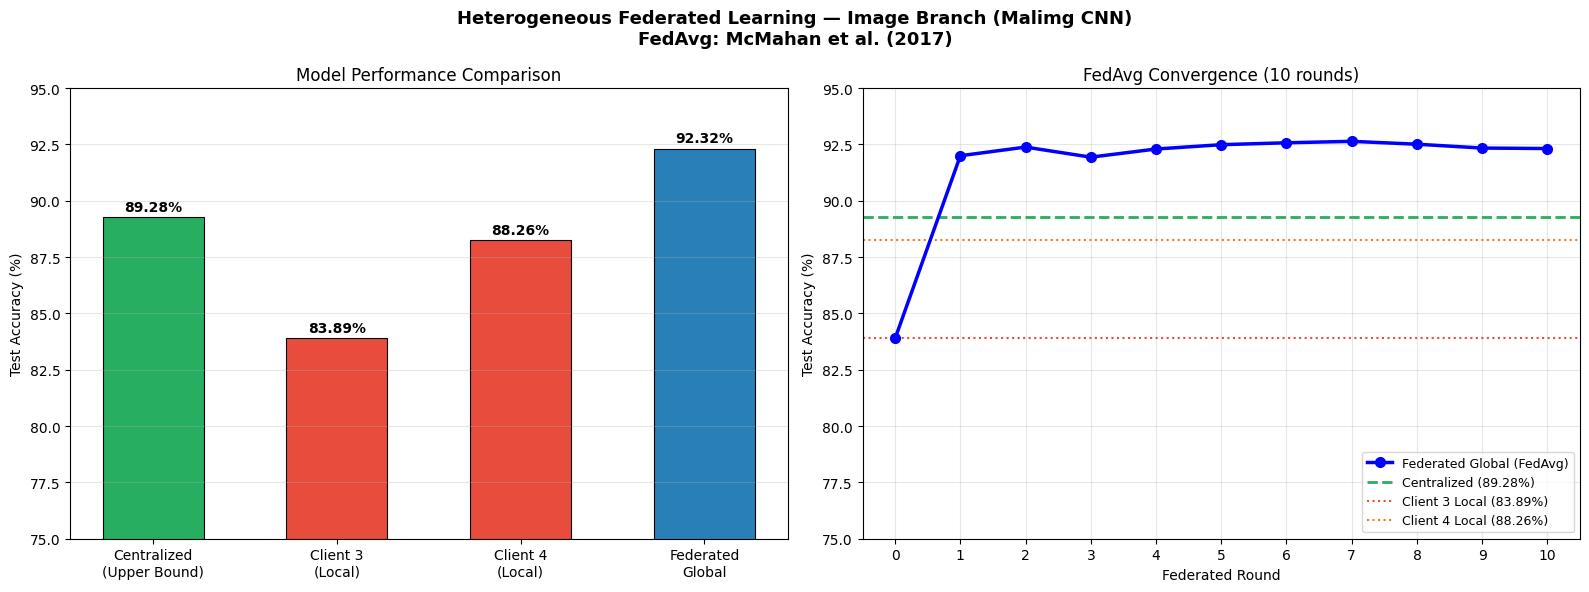

✅ Plot saved


In [13]:
# ═══════════════════════════════════════
# CELL 10 — Results Visualization
# ═══════════════════════════════════════
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Heterogeneous Federated Learning — Image Branch (Malimg CNN)\n'
    'FedAvg: McMahan et al. (2017)',
    fontsize=13, fontweight='bold')

# Bar chart
labels = ['Centralized\n(Upper Bound)', 'Client 3\n(Local)',
          'Client 4\n(Local)', 'Federated\nGlobal']
accs   = [central_acc*100, client3_acc*100,
          client4_acc*100, metrics['global_acc'][-1]*100]
colors = ['#27ae60', '#e74c3c', '#e74c3c', '#2980b9']
bars   = axes[0].bar(labels, accs, color=colors,
                     edgecolor='black', linewidth=0.8, width=0.55)
axes[0].set_ylim([75, 95])
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Model Performance Comparison')
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.15,
                 f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

# Convergence curve
rnds   = metrics['round']
g_accs = [a*100 for a in metrics['global_acc']]
axes[1].plot(rnds, g_accs, 'b-o', linewidth=2.5, markersize=7,
             label='Federated Global (FedAvg)', zorder=3)
axes[1].axhline(central_acc*100, color='#27ae60', linestyle='--',
                linewidth=2, label=f'Centralized ({central_acc*100:.2f}%)')
axes[1].axhline(client3_acc*100, color='#e74c3c', linestyle=':',
                linewidth=1.5, label=f'Client 3 Local ({client3_acc*100:.2f}%)')
axes[1].axhline(client4_acc*100, color='#e67e22', linestyle=':',
                linewidth=1.5, label=f'Client 4 Local ({client4_acc*100:.2f}%)')
axes[1].set_xlabel('Federated Round')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title(f'FedAvg Convergence ({FL_CONFIG["num_rounds"]} rounds)')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([75, 95])
axes[1].set_xticks(rnds)

plt.tight_layout()
plt.savefig(f"{PATHS['output']}/image_federated_results.png",
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved')

In [14]:
# ═══════════════════════════════════════
# CELL 11 — Classification Report
# ═══════════════════════════════════════
from sklearn.metrics import classification_report

y_pred_probs = global_model.predict(
    X_test.astype(np.float32), verbose=0)
y_pred_int = np.argmax(y_pred_probs, axis=1)
y_true_int = np.argmax(y_test, axis=1)

print('CLASSIFICATION REPORT — Federated Global Model')
print('=' * 62)
print(classification_report(
    y_true_int, y_pred_int, target_names=class_names, digits=3))

report = classification_report(
    y_true_int, y_pred_int,
    target_names=class_names, digits=3, output_dict=True)
with open(f"{PATHS['output']}/classification_report.json", 'w') as f:
    json.dump(report, f, indent=2)
print('✅ Classification report saved')

CLASSIFICATION REPORT — Federated Global Model
                precision    recall  f1-score   support

     Adialer.C      1.000     1.000     1.000        56
      Adposhel      1.000     1.000     1.000        74
     Agent.FYI      0.982     1.000     0.991        54
     Allaple.A      1.000     0.999     0.999       669
     Allaple.L      0.992     1.000     0.996       362
 Alueron.gen!J      0.959     1.000     0.979        71
     Amonetize      1.000     0.946     0.972        74
        Androm      0.971     0.907     0.938        75
     Autorun.K      1.000     1.000     1.000        49
     BrowseFox      0.973     0.986     0.980        74
       C2LOP.P      0.976     0.755     0.851        53
   C2LOP.gen!g      0.857     0.917     0.886        72
CoinMinerXMRig      0.667     0.435     0.526        23
       Danabot      0.761     0.680     0.718        75
Dialplatform.B      1.000     0.984     0.992        64
        Dinwod      0.987     1.000     0.993        75


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Generating LIME explainability...
  Running LIME on sample 1/4: Fakerean... 

  0%|          | 0/500 [00:00<?, ?it/s]

done ✅
  Running LIME on sample 2/4: Fasong... 

  0%|          | 0/500 [00:00<?, ?it/s]

done ✅
  Running LIME on sample 3/4: Neshta... 

  0%|          | 0/500 [00:00<?, ?it/s]

done ✅
  Running LIME on sample 4/4: Lolyda.AA2... 

  0%|          | 0/500 [00:00<?, ?it/s]

done ✅


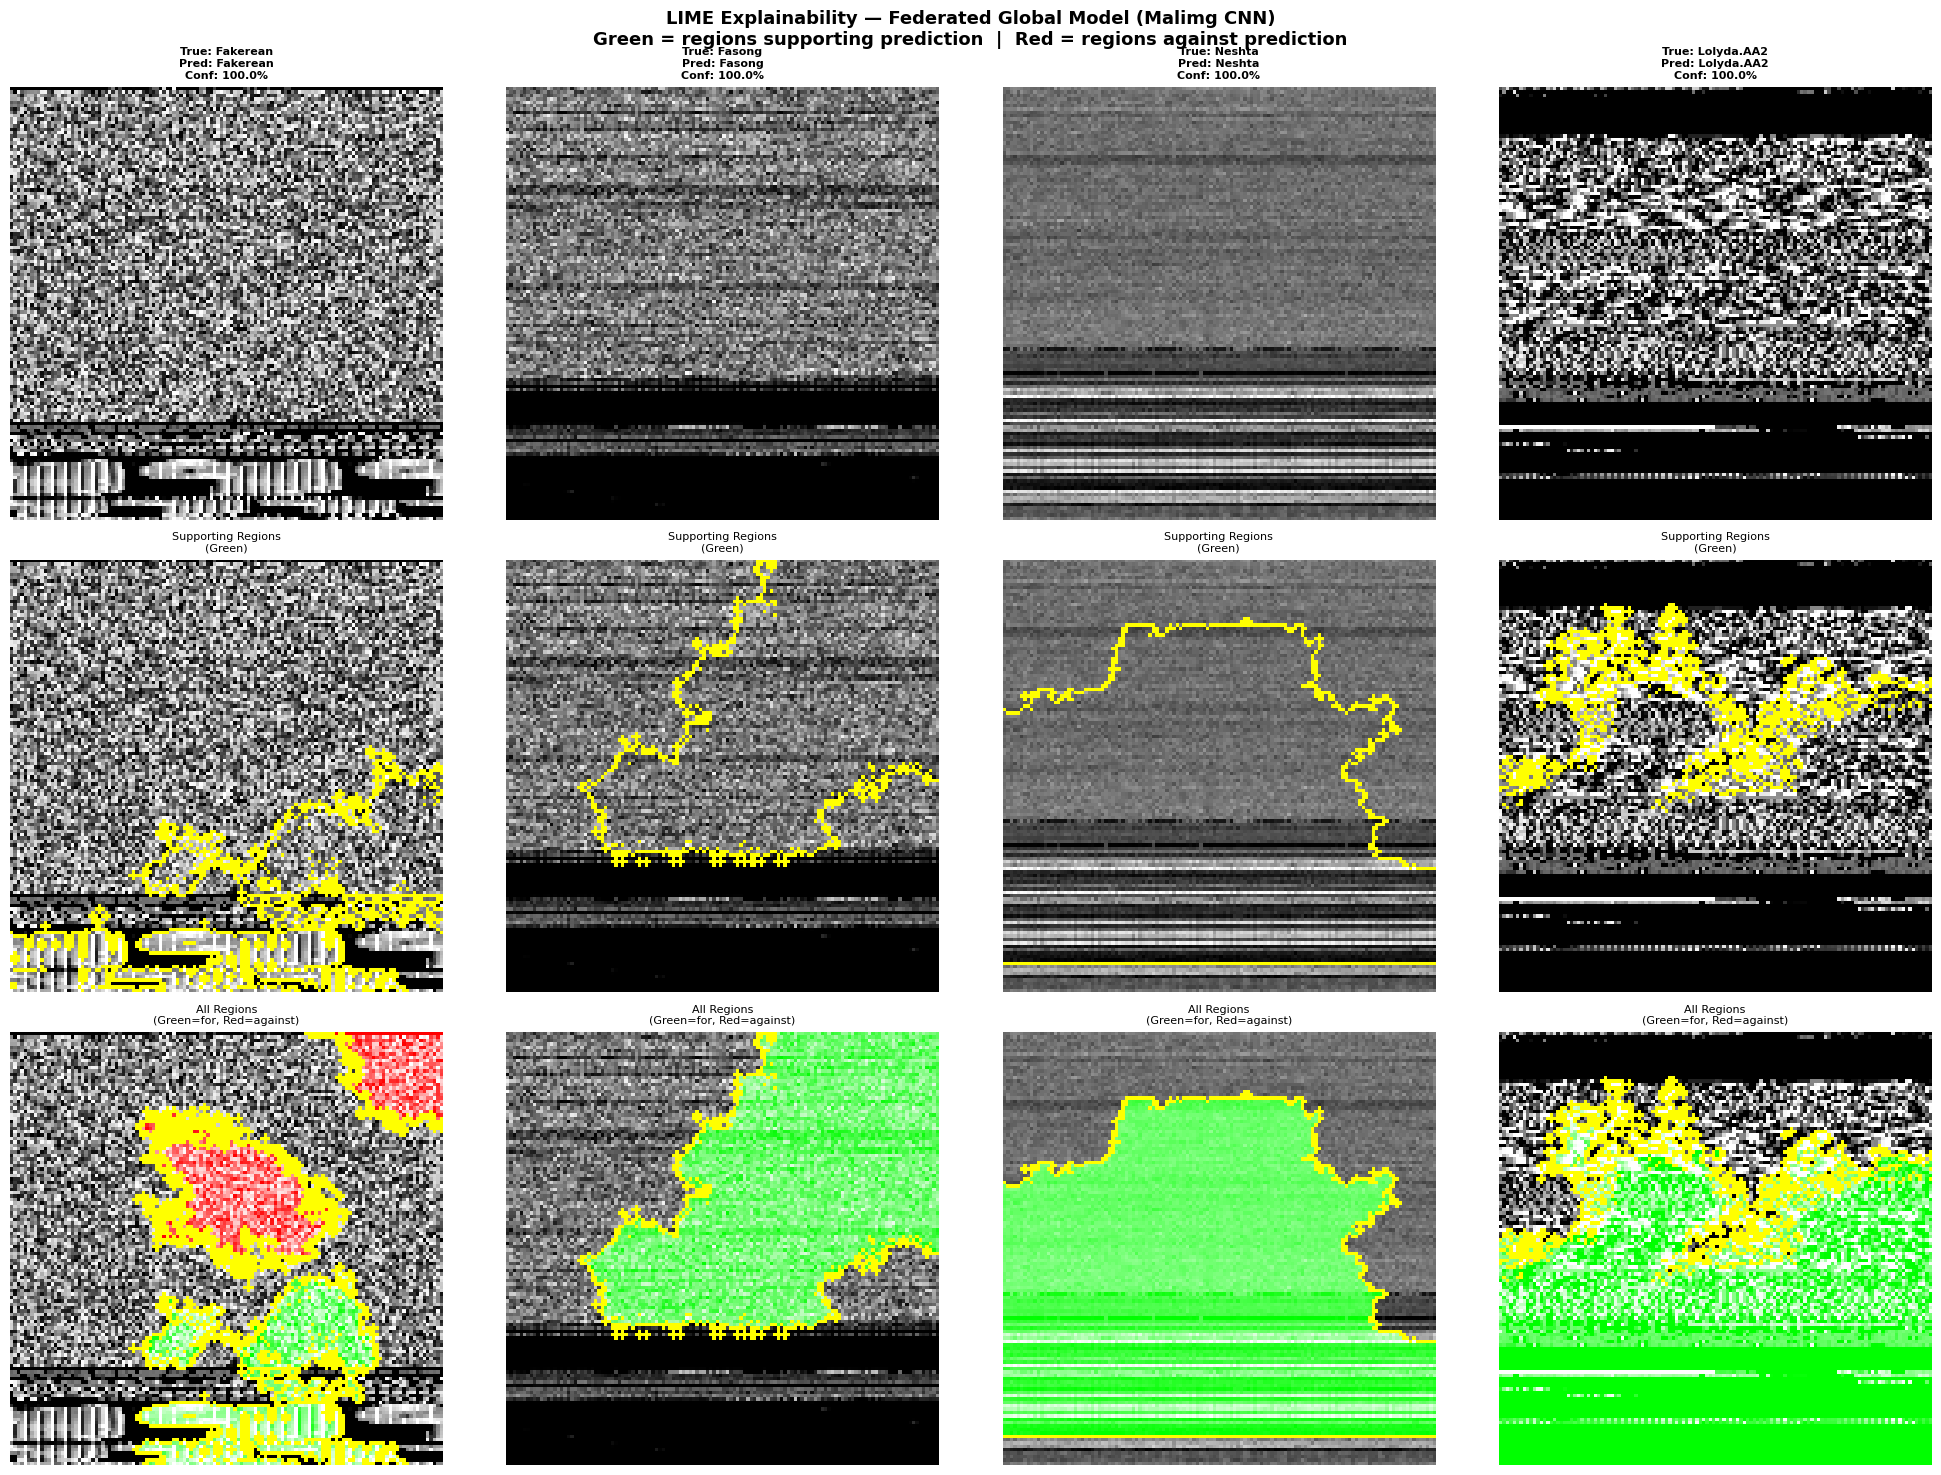

✅ LIME explainability saved → lime_explainability.png


In [24]:
# ═══════════════════════════════════════
# CELL 12 — LIME Explainability
# (Matches what is stated in FYP report)
# ═══════════════════════════════════════
!pip install lime -q

import matplotlib.pyplot as plt
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.color import gray2rgb

print('Generating LIME explainability...')

# LIME explainer
explainer = lime_image.LimeImageExplainer()

def predict_fn(images):
    """
    Wrapper for LIME — takes RGB images (LIME default),
    converts to grayscale single channel, runs through model.
    """
    # LIME sends (N, H, W, 3) — convert to (N, H, W, 1)
    gray = np.mean(images, axis=-1, keepdims=True).astype(np.float32)
    preds = []
    for i in range(0, len(gray), 8):
        batch = gray[i:i+8]
        p = global_model.predict_on_batch(batch)
        preds.append(p)
    return np.vstack(preds)

# Pick 4 correctly classified samples
correct_idx = np.where(y_pred_int == y_true_int)[0][:4]

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle(
    'LIME Explainability — Federated Global Model (Malimg CNN)\n'
    'Green = regions supporting prediction  |  Red = regions against prediction',
    fontsize=13, fontweight='bold'
)

for col, idx in enumerate(correct_idx):
    img        = X_test[idx].astype(np.float32)       # (128,128,1)
    true_lbl   = class_names[y_true_int[idx]]
    pred_lbl   = class_names[y_pred_int[idx]]
    conf       = y_pred_probs[idx][y_pred_int[idx]] * 100

    # LIME needs RGB image (128,128,3)
    img_rgb = gray2rgb(img.squeeze())

    print(f'  Running LIME on sample {col+1}/4: {true_lbl}...', end=' ')

    explanation = explainer.explain_instance(
        img_rgb,
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=500,        # Higher = better but slower
        batch_size=8
    )

    top_label = explanation.top_labels[0]

    # ── Row 0: Original malware image ──
    axes[0, col].imshow(img.squeeze(), cmap='gray')
    axes[0, col].set_title(
        f'True: {true_lbl}\nPred: {pred_lbl}\nConf: {conf:.1f}%',
        fontsize=8, fontweight='bold')
    axes[0, col].axis('off')

    # ── Row 1: LIME positive regions (green = supports prediction) ──
    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )
    axes[1, col].imshow(mark_boundaries(temp, mask), cmap='gray')
    axes[1, col].set_title('Supporting Regions\n(Green)', fontsize=8)
    axes[1, col].axis('off')

    # ── Row 2: LIME all regions (green + red) ──
    temp2, mask2 = explanation.get_image_and_mask(
        top_label,
        positive_only=False,
        num_features=5,
        hide_rest=False
    )
    axes[2, col].imshow(mark_boundaries(temp2, mask2))
    axes[2, col].set_title('All Regions\n(Green=for, Red=against)', fontsize=8)
    axes[2, col].axis('off')

    print('done ✅')

for r, lbl in enumerate(['Original Image', 'LIME: Positive', 'LIME: All']):
    axes[r, 0].set_ylabel(lbl, fontsize=10, fontweight='bold',
                          rotation=90, labelpad=15)

plt.tight_layout()
plt.savefig(f"{PATHS['output']}/lime_explainability.png",
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ LIME explainability saved → lime_explainability.png')